# Paper Ingestion — Loading and Parsing Scientific Papers

## Goal
Scientific papers have a specific structure — Abstract, Introduction, Methods, Results, Discussion.
Standard text loading ignores this structure.
This notebook loads papers and extracts sections separately.

## Why Section-Aware Ingestion?
- Abstract = summary of the paper
- Methods = what was done
- Results = what was found
- Different sections answer different questions

## What We Build
A parser that loads a PDF and separates it into meaningful sections.

In [2]:
import re
import PyPDF2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Load PDF and Extract Raw Text

In [11]:
def load_pdf(path: str) -> str:
    """Extract raw text from a PDF file."""
    text = ""
    with open(path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            extracted = page.extract_text()
            if extracted:
                text += extracted + "\n"
    return text


# Load the paper
pdf_path ="../data/raw/paper.pdf"
raw_text = load_pdf(pdf_path)

print(f"Total characters: {len(raw_text)}")
print(f"Total words: {len(raw_text.split())}")
print(f"\nFirst 500 chars:\n{raw_text[:500]}")

Total characters: 39487
Total words: 5998

First 500 chars:
Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.comNoam Shazeer∗
Google Brain
noam@google.comNiki Parmar∗
Google Research
nikip@google.comJakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.comAidan N. Gomez∗ †
University of Toronto
aidan@cs.toronto.eduŁukasz Kaise


## 2. Extract Sections
Detect and separate paper sections by their headers.

In [14]:
def extract_sections(text: str) -> dict:
    """
    Extract sections from a scientific paper.
    Detects common section headers and splits text accordingly.
    """
    section_headers = [
        "abstract", "introduction", "background", "related work",
        "method", "methods", "model", "experiment", "experiments",
        "result", "results", "discussion", "conclusion", "conclusions",
        "references"
    ]

    lines = text.split("\n")
    sections = {}
    current_section = "preamble"
    sections[current_section] = []

    for line in lines:
        line_lower = line.strip().lower()
        matched = False
        for header in section_headers:
            if line_lower == header or line_lower.startswith(header + ' '):
                current_section = header
                if current_section not in sections:
                    sections[current_section] = []
                matched = True
                break
        if not matched:
            if current_section in sections:
                sections[current_section].append(line)

    # Join and filter
    sections = {
        k: "\n".join(v).strip()
        for k, v in sections.items()
        if len("\n".join(v).strip()) > 50
    }
    return sections


sections = extract_sections(raw_text)

print(f"Sections found: {list(sections.keys())}")
print(f"\nSection lengths:")
for name, content in sections.items():
    print(f"  {name:<20}: {len(content):>6} chars | {len(content.split()):>4} words")

Sections found: ['preamble', 'abstract', 'model', 'results', 'references']

Section lengths:
  preamble            :    586 chars |   68 words
  abstract            :  23445 chars | 3556 words
  model               :   2810 chars |  466 words
  results             :   2958 chars |  450 words
  references          :   9480 chars | 1427 words


## 3. Visualize Section Distribution

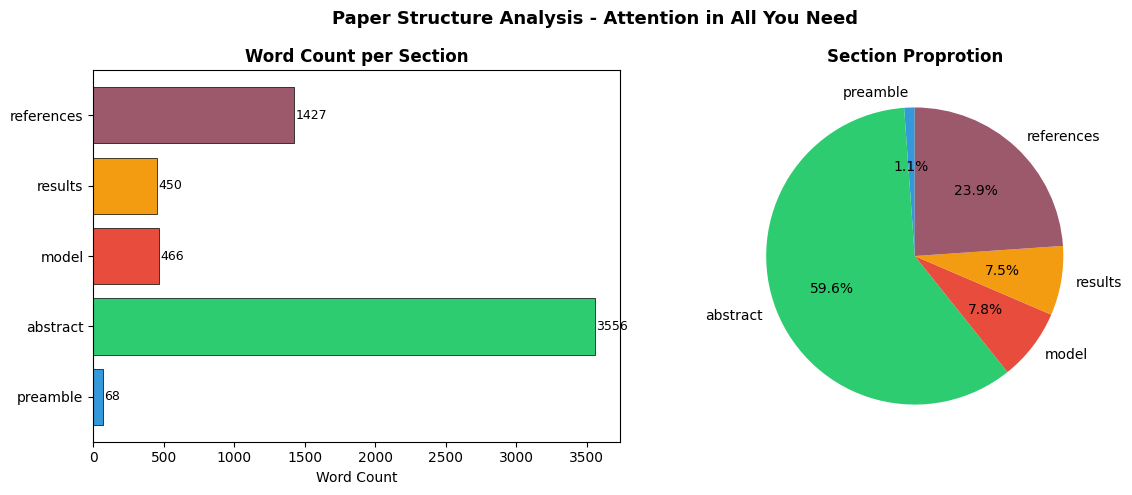

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

names = list(sections.keys())
word_counts = [len(v.split()) for v in sections.values()]

# Chart 1 - Word count per section
colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b596b"][:len(names)]
bars = axes[0].barh(names, word_counts, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("Word Count per Section", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Word Count")
for bar, count in zip(bars, word_counts):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                str(count), va="center", fontsize=9)

# Chart 2 - Proportion pie chart
axes[1].pie(word_counts, labels=names, colors=colors, autopct='%1.1f%%',
           startangle=90)
axes[1].set_title("Section Proprotion", fontsize=12, fontweight="bold")

plt.suptitle("Paper Structure Analysis - Attention in All You Need",
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("paper_structure.png", dpi=300)
plt.show()

## 4. Chunk Sections for Retrieval

In [19]:
def chunk_section(text: str, sentences_per_chunk: int = 3) -> list:
    """Split a section into chunks for retrieval."""
    sentences = re.split(r"(?<=[.!?])\s+", text)
    chunks = []
    for i in range(0, len(sentences), sentences_per_chunk):
        chunk = " ".join(sentences[i:i + sentences_per_chunk])
        if len(chunk.strip()) > 30:
            chunks.append(chunk.strip())
    return chunks

# Chunks all sections
all_chunks = []
for sections_name, content in sections.items():
    chunks = chunk_section(content)
    for chunk in chunks:
        all_chunks.append({
            "section": sections_name,
            "text": chunk,
            "word_count": len(chunk.split())
        })

df_chunks = pd.DataFrame(all_chunks)

print(f"Total chunks: {len(df_chunks)}")
print(f"\nChunks per section:")
print(df_chunks.groupby("section")["text"].count())
print(f"\nSample chunk from abstract:")
print(df_chunks[df_chunks["section"]=="abstract"]["text"].iloc[0][:200])

Total chunks: 124

Chunks per section:
section
abstract      56
model          7
preamble       1
references    52
results        8
Name: text, dtype: int64

Sample chunk from abstract:
The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks that include an encoder and a decoder. The best
performing models also connect the encoder and


## 5. Key Observations

| Section | Words | Chunks | Note |
|---------|-------|--------|------|
| abstract | 3556 | 56 | Oversized — contains intro/methods too |
| references | 1427 | 52 | Large — expected |
| results | 450 | 8 | Well-separated |
| model | 466 | 7 | Well-separated |
| preamble | 68 | 1 | Title and authors |

## Key Insight
PDF text extraction is lossy — section headers are not always preserved.
"Abstract" section captured most of the paper because headers like
"Introduction" and "Methods" were not detected correctly.

For production scientific NLP:
- Use structured formats (XML, HTML) when available
- ArXiv papers have LaTeX source — better for parsing
- PyMuPDF handles headers better than PyPDF2

## Next
Extract scientific entities from the text — methods, datasets, metrics.
-> 02_scientific_ner.ipynb